#### Load necessary modules

In [1]:
import os, sys
from pathlib import Path
script_dir = Path(os.path.dirname(os.path.abspath('')))
module_dir = str(script_dir)
sys.path.insert(0, module_dir + '/modules')
print(module_dir)

# import the rest of the modules
%matplotlib nbagg
%matplotlib inline
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt
import arch
import pandas as pd
import tensorflow_probability as tfp
import time  
import sim
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1 import make_axes_locatable

C:\Users\pinak\Documents\GitHub\fp-solvers


#### Define $p_0$

In [2]:
dtype = 'float32'
c = 2. * np.pi
log_half = np.log(0.5, dtype=dtype)

def left(x, y):
    return np.exp(-((x+1.)**2 + (y+1.)**2)/(2.)) / c

def right(x, y):
    return np.exp(-((x-1.)**2 + (y-1.)**2)/(2.)) / c

def middle(x, y):
    return 0.5 * left(x, y) + 0.5 * right(x, y)

def p0(X):
    x0, x1, x2, x3, x4, x5, x6, x7, x8, x9 = tf.split(X, 10, axis=-1)
    return middle(x0, x1) * middle(x2, x3) * middle(x4, x5) * middle(x6, x7) * middle(x8, x9)
     
locs = np.array([[-1., -1.], [1., 1.]]).astype(dtype)
scales = np.array([[1., 1.], [1., 1.]]).astype(dtype)
weights = np.array([.5, .5]).astype(dtype)
Xs = [tfp.distributions.MultivariateNormalDiag(loc=locs[i], scale_diag=scales[i]) for i in range(len(locs))]
rv0 = tfp.distributions.Mixture(cat=tfp.distributions.Categorical(probs=weights), components=Xs)    

#### Define $p_\infty$

In [3]:
# load learned solution
dim = 10
o1 = tf.ones((1, 1), dtype=dtype)
z1 = tf.zeros((1, 1), dtype=dtype)
n_theta = arch.LSTMForgetNet(50, 3, tf.float32, name="circle10D")
n_theta.load_weights('../circle-fp/data/10D/460/{}'.format(n_theta.name)).expect_partial()


def p_inf(X):
    return np.exp(n_theta(X))

def p_inf_45(x4, x5):
    return np.exp(n_theta(z1, z1, z1, z1, o1*x4, o1*x5, z1, z1, z1, z1))[0][0]

#### Define the $h$ equation

In [4]:
# define p-drift
def mu_10(X):
    x0, x1, x2, x3, x4, x5, x6, x7, x8, x9 = tf.split(X, 10, axis=-1)
    z0 = -4. * (x0*x0 + x1*x1 - 1.)
    z1 = -4. * (x2*x2 + x3*x3 - 1.)
    z2 = -4. * (x4*x4 + x5*x5 - 1.)
    z3 = -4. * (x6*x6 + x7*x7 - 1.)
    z4 = -4. * (x8*x8 + x9*x9 - 1.)
    return tf.concat([x0*z0, x1*z0, x2*z1, x3*z1, x4*z2, x5*z2, x6*z3, x7*z3, x8*z4, x9*z4], axis=-1)

def mu_2(X):
    x0, x1 = tf.split(X, 2, axis=-1)
    z0 = -4. * (x0*x0 + x1*x1 - 1.)
    return tf.concat([x0*z0, x1*z0], axis=-1)

# define diffusion
sigma = np.sqrt(2., dtype=dtype)
D = sigma**2 / 2.


# define h-drift
@tf.function
def h_mu(X):
    x0, x1, x2, x3, x4, x5, x6, x7, x8, x9 = tf.split(X, 10, axis=-1)
    with tf.GradientTape() as tape:
        tape.watch([x0, x1, x2, x3, x4, x5, x6, x7, x8, x9])
        n_ = n_theta(x0, x1, x2, x3, x4, x5, x6, x7, x8, x9) 
    grad_n = tf.concat(tape.gradient(n_, [x0, x1, x2, x3, x4, x5, x6, x7, x8, x9]), axis=-1)
    return sigma**2*grad_n - mu_10(X)

# define h0
def h0(X):
    return p0(X) / p_inf(X)

#### Compute the Monte-Carlo solution

In [5]:
n_particles = int(1e5)
n_subdivs = 100
save_folder = '../circle-fp/data/10D'
n_steps = 5
dt = 0.01
t = dt * n_steps

X0 =  rv0.sample(n_particles).numpy()
mc_prob = sim.MCProb(save_folder, n_subdivs, lambda X: mu_2(X).numpy(), sigma,\
                     X0, tick_size=20, title_size=20, cbar_tick_size=15)
mc_prob.ready(n_steps=n_steps, dt=dt, lims=None)
z_1m = mc_prob.compute_p2(0, 1, save=False) 
nonzero_idx = list(zip(*np.where(z_1m > 0.)))

Time taken by propagate is 0.1898043155670166 seconds
Time taken by set_grid is 0.2240142822265625 seconds
Time taken by assign_pts is 0.26773715019226074 seconds
Time taken by ready is 0.6815557479858398 seconds
Time taken by compute_p2 is 0.2664926052093506 seconds


#### Compute the Feynman-Kac solution

In [6]:
n_repeats = 100
o = tf.ones((n_repeats, 1), dtype=dtype)
z = tf.zeros((n_repeats, 1), dtype=dtype)

def get_endpts(x4, x5):
    X = tf.concat([z, z, z, z, o*x4, o*x5, z, z, z, z], axis=-1).numpy()
    dW = np.random.normal(scale=np.sqrt(dt), size=(n_steps, X.shape[0], dim)).astype(dtype)
    for step in range(n_steps):
        X += h_mu(X).numpy() * dt + sigma * dW[step]
    return X 

def fk(x4, x5):
    X = get_endpts(x4, x5)
    return p_inf_45(x4, x5) * (h0(X).sum()) / n_repeats

# calculate the learned probability
grid = mc_prob.get_grid()
low = grid.mins
high = grid.maxs
x4 = np.linspace(low[0], high[0], num=n_subdivs+1).astype(dtype)[1:]
x5 = np.linspace(low[1], high[1], num=n_subdivs+1).astype(dtype)[1:]        
z_1l = np.zeros((n_subdivs, n_subdivs))
start = time.time()
for i, j in nonzero_idx:
    print('Calculating probability for grid at {}'.format((i, j)), end='\r')
    z_1l[i][j] = fk(x4[i], x5[j])
end = time.time()
print('Time taken by Feynman-Kac computation = {}s'.format(end - start))

Time taken by Feynman-Kac computation 266.28938603401184s


#### Plot solutions

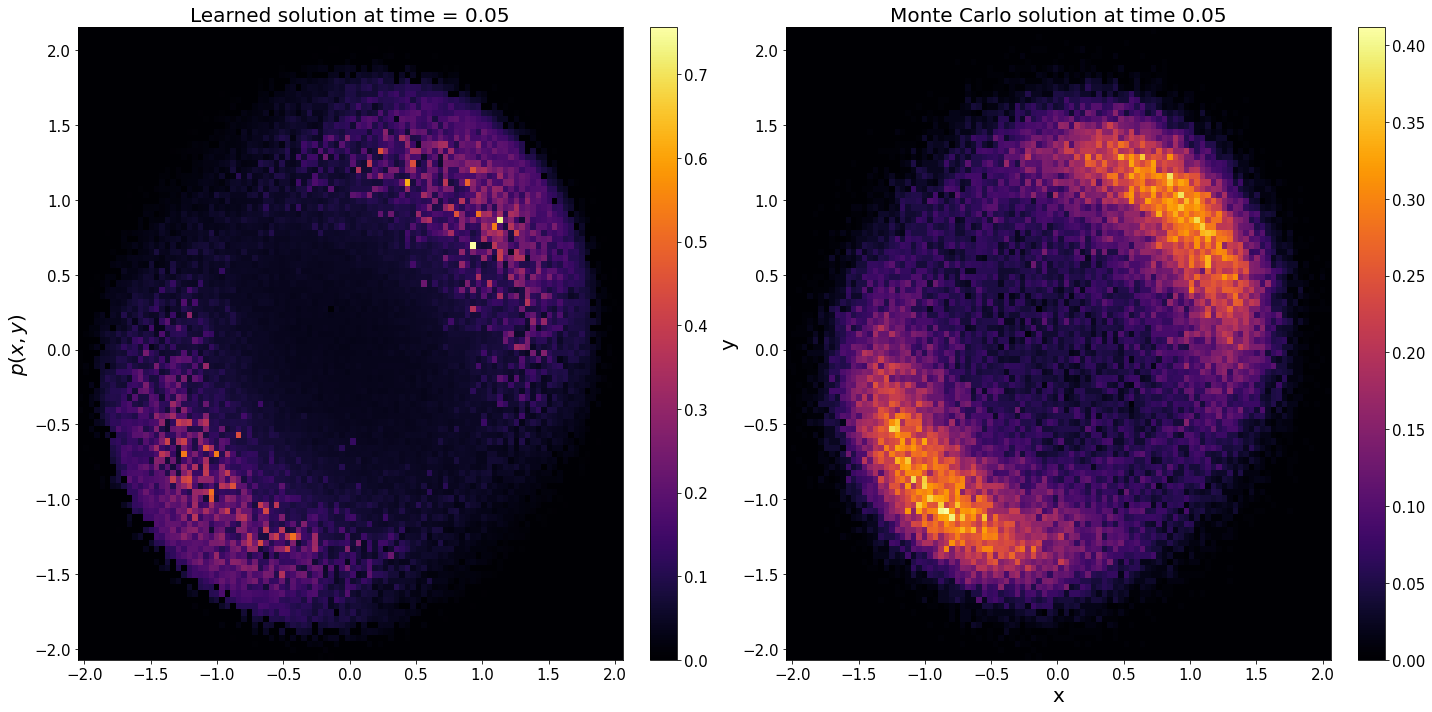

In [7]:
# set up plotting parameters
scale = 5
xlabel_size = ylabel_size = 15 + scale
tick_size = 10 + scale
legend_size = 15 + scale
title_size = 15 + scale
cbar_tick_size = 10 + scale


x_ = np.linspace(low[0], high[0], num=n_subdivs, endpoint=True).astype(dtype)
y_ = np.linspace(low[1], high[1], num=n_subdivs, endpoint=True).astype(dtype)


fig_all = plt.figure(figsize=(20, 10))
ax_1l = fig_all.add_subplot(121) 
ax_1m = fig_all.add_subplot(122)


div_1 = make_axes_locatable(ax_1l)
cax_1 = div_1.append_axes('right', '5%', '5%')


div_4 = make_axes_locatable(ax_1m)
cax_4 = div_4.append_axes('right', '5%', '5%')



z_1m  /= (z_1m.sum() * grid.h[0] * grid.h[1])
im = ax_1m.pcolormesh(x_, y_, z_1m.T, cmap='inferno', shading='auto')
cbar = fig_all.colorbar(im, cax=cax_4, ax=ax_1m)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_1m.set_aspect("auto")



ax_1m.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1m.tick_params(axis='both', which='minor', labelsize=tick_size)


ax_1m.set_title('Monte Carlo solution at time {:.2f}'.format(t), fontsize=title_size)
ax_1m.set_xlabel('x', fontsize=xlabel_size)
ax_1m.set_ylabel('y', fontsize=ylabel_size)


ax_1l.clear()
cax_1.cla()
z_1l /= (z_1l.sum() * grid.h[0] * grid.h[1])
im = ax_1l.pcolormesh(x_, y_, z_1l.T, cmap='inferno', shading='auto')
ax_1l.set_title('Learned solution at time = {:.2f}'.format(t), fontsize=title_size)
ax_1l.tick_params(axis='both', which='major', labelsize=tick_size)
ax_1l.tick_params(axis='both', which='minor', labelsize=tick_size)
cbar = fig_all.colorbar(im, cax=cax_1, ax=ax_1l)
cbar.ax.tick_params(labelsize=cbar_tick_size)
#cbar.formatter.set_powerlimits((0, 0))
ax_1l.set_aspect("auto")


fig_all.subplots_adjust(wspace=1.0, hspace=0.4)

ax_1l.set_ylabel(r'$p(x, y)$', fontsize=ylabel_size)
plt.tight_layout()
plt.savefig('../plots/10D-time.png')

In [8]:
get_endpts(x4[5], x5[9])

array([[ 1.24239594e-01, -6.80861920e-02,  2.58955657e-01,
         1.14094183e-01, -1.52414780e+02, -1.37124588e+02,
        -3.50048840e-01,  6.37618721e-01, -4.33128178e-01,
        -1.61626309e-01],
       [-3.41660023e-01, -1.52897596e-01, -9.88756195e-02,
        -3.65406275e-04, -4.94550781e+01, -5.19447021e+01,
         1.91983864e-01, -1.85536891e-01,  6.48521259e-02,
         4.16596681e-01],
       [-3.58095795e-01, -2.24025562e-01, -5.25696501e-02,
         1.21385559e-01, -3.52670631e+01, -3.01989269e+01,
         2.38443106e-01, -3.27266514e-01, -2.18495727e-03,
         4.58653361e-01],
       [ 1.20532721e-01,  3.24770808e-05,  3.04080039e-01,
         4.44110930e-02, -3.37915497e+01, -3.17080116e+01,
         3.90950680e-01,  2.25183107e-02, -1.22053742e-01,
        -2.78452814e-01],
       [ 5.19177079e-01, -2.04026699e-01,  4.87699687e-01,
         9.60628390e-01, -7.50402069e+01, -5.91526642e+01,
         3.10049057e-01, -4.19341661e-02, -3.48263800e-01,
         2.